<a href="https://colab.research.google.com/github/Dhanushiya-tech/Portfolio-sample/blob/main/League_of_Legends_Match_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [3]:
from google.colab import files
uploaded = files.upload()

Saving league_of_legends_data_large.csv to league_of_legends_data_large.csv


In [4]:
df = pd.read_csv("league_of_legends_data_large.csv")
df.head()

,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
0,0,16,6,19,17088,231,11,7,15367
1,1,8,8,5,14865,259,10,2,38332
2,0,0,17,11,15919,169,14,5,24642
3,0,19,11,1,11534,264,14,3,15789
4,0,12,7,6,18926,124,15,7,40268


In [6]:
X = df.drop("win", axis=1)
y = df["win"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [8]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model = LogisticRegressionModel(X_train.shape[1])

In [9]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.01)

In [10]:
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.7199556231498718
Epoch 10, Loss: 0.6940668225288391
Epoch 20, Loss: 0.6855005621910095
Epoch 30, Loss: 0.6836081147193909
Epoch 40, Loss: 0.6828588843345642
Epoch 50, Loss: 0.6826891899108887
Epoch 60, Loss: 0.6826874017715454
Epoch 70, Loss: 0.6826507449150085
Epoch 80, Loss: 0.6826403737068176
Epoch 90, Loss: 0.6826429963111877


In [11]:
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.44


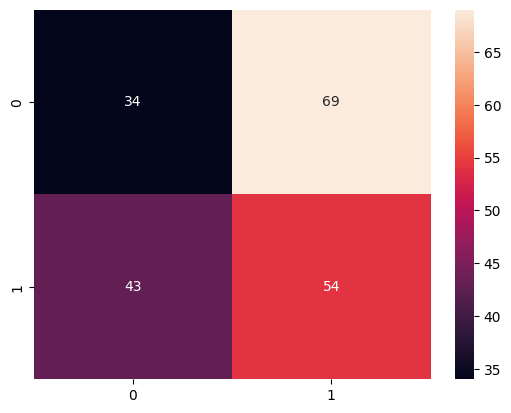

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

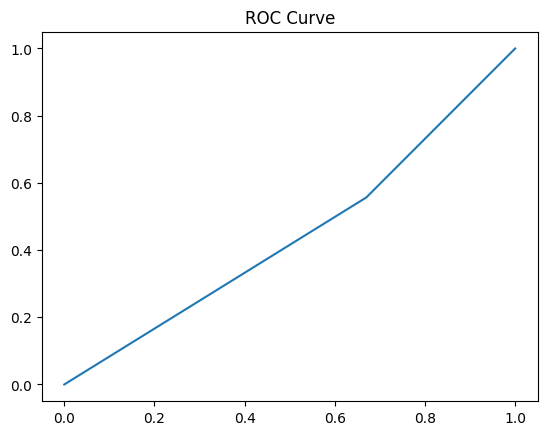

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

In [15]:
torch.save(model.state_dict(), "model.pth")